<a href="https://colab.research.google.com/github/JIUN99/SLM-Driven-Autonomous-Agent-for-Real-Time-Stock-Data-Processing-A-Proof-of-Concept-Evaluation/blob/main/FYP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## STEP 1 — Install all libraries
*Run this first. It will take about 3–5 minutes.*

In [ ]:
import subprocess, sys

# Install all packages, letting pip resolve compatible versions.
# Note: This will take a few minutes.
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
    'numpy', 'yfinance', 'pandas-ta', 'scikit-learn',
    'xgboost', 'torch', 'transformers', 'optimum[onnxruntime]',
    'onnx', 'onnxruntime', 'datasets', 'codecarbon',
    'backtrader', 'matplotlib', 'seaborn', 'statsmodels'], check=True)

print('\n✅ All packages installed. NOW RESTART RUNTIME:')
print('   Runtime menu → Restart session → then run from STEP 2 onwards')
print('   (Do NOT re-run this cell after restarting)')


✅ All packages installed. NOW RESTART RUNTIME:
   Runtime menu → Restart session → then run from STEP 2 onwards
   (Do NOT re-run this cell after restarting)



## STEP 2 — Download historical stock data
*Downloads 6 years of daily price data for 10 US stocks. Takes about 1 minute.*

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

TICKERS = ['AAPL','MSFT','GOOGL','AMZN','TSLA','JPM','GS','XOM','JNJ','PG']
START = '2018-01-01'
END   = '2023-12-31'

print('Downloading stock data...')
raw = yf.download(TICKERS, start=START, end=END, auto_adjust=True,
                  progress=False, group_by='ticker')

# Build per-ticker DataFrames cleanly
ticker_data = {}
for t in TICKERS:
    try:
        df = raw[t].copy().dropna()
        df.columns = [c.lower() for c in df.columns]
        ticker_data[t] = df
        print(f'  {t}: {len(df)} rows')
    except Exception as e:
        print(f'  {t}: FAILED — {e}')

print(f'\n✅ Downloaded data for {len(ticker_data)} tickers')
print(f'   Sample columns: {list(ticker_data["AAPL"].columns)}')
ticker_data['AAPL'].tail(3)

  AAPL: 1509 rows
  MSFT: 1509 rows
  GOOGL: 1509 rows
  AMZN: 1509 rows
  TSLA: 1509 rows
  JPM: 1509 rows
  GS: 1509 rows
  XOM: 1509 rows
  JNJ: 1509 rows
  PG: 1509 rows

✅ Downloaded data for 10 tickers
   Sample columns: ['open', 'high', 'low', 'close', 'volume']


,open,high,low,close,volume
Date,,,,,
2023-12-27,190.335527,191.334217,188.951188,190.988129,48087700
2023-12-28,191.967060,192.481244,191.007915,191.413330,34049900
2023-12-29,191.729738,192.224141,189.584027,190.375076,42672100


In [ ]:
# DIAGNOSTIC — run this to see what the data looks like
print("=== ticker_data keys ===")
print(list(ticker_data.keys()))

print("\n=== AAPL columns ===")
print(ticker_data['AAPL'].columns.tolist())

print("\n=== AAPL first 3 rows ===")
print(ticker_data['AAPL'].head(3))

print("\n=== AAPL dtypes ===")
print(ticker_data['AAPL'].dtypes)

print("\n=== AAPL shape ===")
print(ticker_data['AAPL'].shape)

=== ticker_data keys ===
['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'JPM', 'GS', 'XOM', 'JNJ', 'PG']

=== AAPL columns ===
['open', 'high', 'low', 'close', 'volume']

=== AAPL first 3 rows ===
                 open       high        low      close     volume
Date                                                             
2018-01-02  39.776186  40.276427  39.565802  40.267075  102223600
2018-01-03  40.330191  40.802382  40.196951  40.260063  118071600
2018-01-04  40.332525  40.549921  40.224998  40.447067   89738400

=== AAPL dtypes ===
open      float64
high      float64
low       float64
close     float64
volume      int64
dtype: object

=== AAPL shape ===
(1509, 5)


## STEP 3 — Build features (technical indicators)
*Computes 18 technical indicators for each stock.*

In [ ]:
import pandas_ta as ta

def build_features(ticker):
    df = ticker_data[ticker].copy()

    # Trend
    df['sma_5']   = ta.sma(df['close'], length=5)
    df['sma_10']  = ta.sma(df['close'], length=10)
    df['sma_20']  = ta.sma(df['close'], length=20)
    df['ema_5']   = ta.ema(df['close'], length=5)
    df['ema_10']  = ta.ema(df['close'], length=10)
    df['ema_20']  = ta.ema(df['close'], length=20)

    # Momentum
    df['rsi_14']  = ta.rsi(df['close'], length=14)
    macd = ta.macd(df['close'])
    df['macd']    = macd['MACD_12_26_9'] if macd is not None else np.nan

    # Volatility
    bb = ta.bbands(df['close'], length=20)
    if bb is not None:
        cols = bb.columns.tolist()
        upper = [c for c in cols if c.startswith('BBU')][0]
        lower = [c for c in cols if c.startswith('BBL')][0]
        mid   = [c for c in cols if c.startswith('BBM')][0]
        df['bb_width'] = (bb[upper] - bb[lower]) / bb[mid]
    else:
        df['bb_width'] = np.nan
    df['atr_14'] = ta.atr(df['high'], df['low'], df['close'], length=14)

    # Volume
    df['obv']      = ta.obv(df['close'], df['volume'])
    df['vol_sma5'] = df['volume'].rolling(5).mean()
    df['vol_ratio']= df['volume'] / df['vol_sma5'].replace(0, np.nan)

    # Returns
    df['ret_1d']  = df['close'].pct_change(1)
    df['ret_5d']  = df['close'].pct_change(5)
    df['ret_20d'] = df['close'].pct_change(20)

    # Target: next day up >= 0.5%
    df['target'] = (df['close'].shift(-1) >= df['close'] * 1.005).astype(int)
    df['ticker'] = ticker
    return df.dropna()

# Build features per ticker FIRST, then concat
all_dfs = []
for t in TICKERS:
    try:
        feat_df = build_features(t)
        print(f'  {t}: {len(feat_df)} rows after features')
        all_dfs.append(feat_df)
    except Exception as e:
        print(f'  {t}: FAILED — {e}')

# Concat WITHOUT sorting — preserve per-ticker integrity
data = pd.concat(all_dfs, ignore_index=False)

FEATURE_COLS = ['sma_5','sma_10','sma_20','ema_5','ema_10','ema_20',
                'rsi_14','macd','bb_width','atr_14','obv','vol_sma5',
                'vol_ratio','ret_1d','ret_5d','ret_20d']

print(f'\n✅ Feature matrix: {len(data):,} samples, {len(FEATURE_COLS)} features')
print(f'   Class balance — Up: {data.target.mean():.1%}  Down: {1-data.target.mean():.1%}')
print(f'   NaN check: {data[FEATURE_COLS].isna().sum().sum()} NaN values remaining')
data[FEATURE_COLS + ['target']].tail(3)

  AAPL: 1484 rows after features
  MSFT: 1484 rows after features
  GOOGL: 1484 rows after features
  AMZN: 1484 rows after features
  TSLA: 1484 rows after features
  JPM: 1484 rows after features
  GS: 1484 rows after features
  XOM: 1484 rows after features
  JNJ: 1484 rows after features
  PG: 1484 rows after features

✅ Feature matrix: 14,840 samples, 16 features
   Class balance — Up: 37.9%  Down: 62.1%
   NaN check: 0 NaN values remaining


,sma_5,sma_10,sma_20,ema_5,ema_10,ema_20,rsi_14,macd,bb_width,atr_14,obv,vol_sma5,vol_ratio,ret_1d,ret_5d,ret_20d,target
Date,,,,,,,,,,,,,,,,,
2023-12-27,135.925870,136.309047,137.770519,136.381654,136.559887,137.456647,46.077121,-1.132181,0.079941,1.795711,608021800.0,5277320.0,0.865856,0.000822,-0.000753,-0.040909,0
2023-12-28,136.266876,136.042049,137.517574,136.429586,136.553626,137.367961,45.073673,-1.065020,0.076016,1.735700,602998800.0,4749160.0,1.057661,-0.002259,0.012647,-0.035731,1
2023-12-29,136.694077,136.218173,137.190616,136.714486,136.686473,137.359992,48.063557,-0.939731,0.062719,1.694030,608299700.0,4588400.0,1.155283,0.005558,0.015805,-0.045467,0


## STEP 4 — Train/test split (strict temporal boundary)
*Training: 2018–2021. Test includes COVID crash (2020) and 2022 inflation spike.*

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler

TRAIN_END = '2021-12-31'
TEST_START = '2022-01-01'

train = data[data.index <= TRAIN_END]
test  = data[data.index >= TEST_START]

# Define regime sub-periods for robustness evaluation
covid    = data[(data.index >= '2020-02-01') & (data.index <= '2020-04-30')]
inflation = data[(data.index >= '2022-06-01') & (data.index <= '2022-10-31')]
stable   = data[(data.index >= '2023-01-01') & (data.index <= '2023-12-31')]

X_train = train[FEATURE_COLS].values
y_train = train['target'].values
X_test  = test[FEATURE_COLS].values
y_test  = test['target'].values

# Standardise features (fit only on train)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'✅ Train samples: {len(X_train):,}  |  Test samples: {len(X_test):,}')
print(f'   COVID sub-period: {len(covid):,} samples')
print(f'   Inflation sub-period: {len(inflation):,} samples')
print(f'   Stable 2023 sub-period: {len(stable):,} samples')

✅ Train samples: 9,830  |  Test samples: 5,010
   COVID sub-period: 620 samples
   Inflation sub-period: 1,060 samples
   Stable 2023 sub-period: 2,500 samples


## STEP 5 — Baseline models
*Trains Logistic Regression, XGBoost, and LSTM. Records F1, AUC, and latency.*

In [ ]:
import time
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, roc_auc_score
from xgboost import XGBClassifier
import torch
import torch.nn as nn

results = {}  # will store all results here

# ── Helper: measure latency (95th percentile over 200 runs) ──
def measure_latency_ms(predict_fn, X_sample, n=200):
    times = []
    for _ in range(n):
        t0 = time.perf_counter()
        predict_fn(X_sample)
        times.append((time.perf_counter() - t0) * 1000)
    return float(np.percentile(times, 95))

# ── Helper: evaluate on a subset ──
def evaluate(predict_fn, X, y):
    preds = predict_fn(X)
    f1  = f1_score(y, preds, average='macro', zero_division=0)
    try:
        auc = roc_auc_score(y, preds)
    except:
        auc = float('nan')
    return round(f1, 4), round(auc, 4)

# ════════════════════════════════════════
# BASELINE 1: Logistic Regression
# ════════════════════════════════════════
print('Training Logistic Regression...')
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)
lr_pred = lambda X: lr.predict(X)
f1, auc = evaluate(lr_pred, X_test_sc, y_test)
lat = measure_latency_ms(lambda X: lr.predict(X[:1]), X_test_sc)
f1_covid, _ = evaluate(lr_pred, scaler.transform(covid[FEATURE_COLS].values), covid['target'].values)
f1_inf, _   = evaluate(lr_pred, scaler.transform(inflation[FEATURE_COLS].values), inflation['target'].values)
f1_stab, _  = evaluate(lr_pred, scaler.transform(stable[FEATURE_COLS].values), stable['target'].values)
results['Logistic Regression'] = {'F1': f1, 'AUC': auc, 'Latency_p95_ms': round(lat,2),
    'F1_covid': f1_covid, 'F1_inflation': f1_inf, 'F1_stable': f1_stab}
print(f'  ✅ LR — F1: {f1:.4f}  AUC: {auc:.4f}  Latency: {lat:.2f}ms')

# ════════════════════════════════════════
# BASELINE 2: XGBoost
# ════════════════════════════════════════
print('Training XGBoost...')
xgb = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                    use_label_encoder=False, eval_metric='logloss',
                    random_state=42, verbosity=0)
xgb.fit(X_train_sc, y_train)
xgb_pred = lambda X: xgb.predict(X)
f1, auc = evaluate(xgb_pred, X_test_sc, y_test)
lat = measure_latency_ms(lambda X: xgb.predict(X[:1]), X_test_sc)
f1_covid, _ = evaluate(xgb_pred, scaler.transform(covid[FEATURE_COLS].values), covid['target'].values)
f1_inf, _   = evaluate(xgb_pred, scaler.transform(inflation[FEATURE_COLS].values), inflation['target'].values)
f1_stab, _  = evaluate(xgb_pred, scaler.transform(stable[FEATURE_COLS].values), stable['target'].values)
results['XGBoost'] = {'F1': f1, 'AUC': auc, 'Latency_p95_ms': round(lat,2),
    'F1_covid': f1_covid, 'F1_inflation': f1_inf, 'F1_stable': f1_stab}
print(f'  ✅ XGB — F1: {f1:.4f}  AUC: {auc:.4f}  Latency: {lat:.2f}ms')

# ════════════════════════════════════════
# BASELINE 3: LSTM
# ════════════════════════════════════════
print('Training LSTM (this takes ~5 mins)...')

SEQ_LEN = 20
def make_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(seq_len, len(X)):
        Xs.append(X[i-seq_len:i])
        ys.append(y[i])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.int64)

Xtr_seq, ytr_seq = make_sequences(X_train_sc, y_train, SEQ_LEN)
Xte_seq, yte_seq = make_sequences(X_test_sc,  y_test,  SEQ_LEN)

class LSTMModel(nn.Module):
    def __init__(self, in_dim, hidden=64, layers=2):
        super().__init__()
        self.lstm = nn.LSTM(in_dim, hidden, layers, batch_first=True, dropout=0.2)
        self.fc   = nn.Linear(hidden, 2)
    def forward(self, x):
        _, (h, _) = self.lstm(x)
        return self.fc(h[-1])

device = 'cuda' if torch.cuda.is_available() else 'cpu'
lstm_model = LSTMModel(len(FEATURE_COLS)).to(device)
opt = torch.optim.Adam(lstm_model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(torch.tensor(Xtr_seq), torch.tensor(ytr_seq)),
    batch_size=256, shuffle=True)

for epoch in range(20):
    lstm_model.train()
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad(); loss_fn(lstm_model(xb), yb).backward(); opt.step()
    if (epoch+1) % 5 == 0: print(f'    Epoch {epoch+1}/20 done')

lstm_model.eval()
with torch.no_grad():
    preds_lstm = lstm_model(torch.tensor(Xte_seq).to(device)).argmax(1).cpu().numpy()
f1  = f1_score(yte_seq, preds_lstm, average='macro', zero_division=0)
auc = roc_auc_score(yte_seq, preds_lstm)
lat = measure_latency_ms(
    lambda X: lstm_model(torch.tensor(X[:1:1]).to(device)).argmax(1).cpu().numpy(),
    Xte_seq)

def lstm_eval_sub(X_sub, y_sub):
    if len(X_sub) < SEQ_LEN: return float('nan')
    Xs, ys = make_sequences(X_sub, y_sub, SEQ_LEN)
    with torch.no_grad():
        p = lstm_model(torch.tensor(Xs).to(device)).argmax(1).cpu().numpy()
    return round(f1_score(ys, p, average='macro', zero_division=0), 4)

results['LSTM'] = {
    'F1': round(f1,4), 'AUC': round(auc,4), 'Latency_p95_ms': round(lat,2),
    'F1_covid': lstm_eval_sub(scaler.transform(covid[FEATURE_COLS].values), covid['target'].values),
    'F1_inflation': lstm_eval_sub(scaler.transform(inflation[FEATURE_COLS].values), inflation['target'].values),
    'F1_stable': lstm_eval_sub(scaler.transform(stable[FEATURE_COLS].values), stable['target'].values)
}
print(f'  ✅ LSTM — F1: {f1:.4f}  AUC: {auc:.4f}  Latency: {lat:.2f}ms')

Training Logistic Regression...
  ✅ LR — F1: 0.4426  AUC: 0.5112  Latency: 4.25ms
Training XGBoost...
  ✅ XGB — F1: 0.5075  AUC: 0.5120  Latency: 2.92ms
Training LSTM (this takes ~5 mins)...
    Epoch 5/20 done
    Epoch 10/20 done
    Epoch 15/20 done
    Epoch 20/20 done
  ✅ LSTM — F1: 0.4655  AUC: 0.5064  Latency: 8.58ms


## STEP 6 — Deploy SLM (FinGPT off-the-shelf, ONNX INT8)
*Downloads FinGPT, exports to ONNX, quantises to INT8, runs inference. Takes ~20 mins.*

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from optimum.onnxruntime import ORTModelForSequenceClassification
from optimum.onnxruntime.configuration import AutoQuantizationConfig
from optimum.onnxruntime import ORTQuantizer
import onnxruntime as ort
import os

# We use FinGPT sentiment model — pre-trained on financial news
# It classifies text as positive/negative/neutral which we map to buy/sell
SLM_NAME = 'ProsusAI/finbert'  # FinBERT: 110M params, finance-trained, free
SLM_DIR  = '/content/finbert_onnx'
QUANT_DIR = '/content/finbert_int8'

print('Step 6a: Downloading FinBERT and exporting to ONNX...')
print('(This downloads ~450MB — takes 5–10 minutes)')

tokenizer = AutoTokenizer.from_pretrained(SLM_NAME)

# Export to ONNX format
ort_model = ORTModelForSequenceClassification.from_pretrained(
    SLM_NAME, export=True)
ort_model.save_pretrained(SLM_DIR)
tokenizer.save_pretrained(SLM_DIR)
print('✅ ONNX export complete')

print('Step 6b: Applying INT8 quantisation...')
quantizer = ORTQuantizer.from_pretrained(SLM_DIR)
qconfig = AutoQuantizationConfig.avx512_vnni(is_static=False, per_channel=False)
quantizer.quantize(save_dir=QUANT_DIR, quantization_config=qconfig)
print('✅ INT8 quantisation complete')

# Check file size reduction
def dir_size_mb(path):
    total = sum(os.path.getsize(os.path.join(r,f))
                for r,_,files in os.walk(path) for f in files)
    return round(total / 1e6, 1)

print(f'   Original ONNX model: {dir_size_mb(SLM_DIR)} MB')
print(f'   INT8 quantised model: {dir_size_mb(QUANT_DIR)} MB')

Multiple distributions found for package optimum. Picked distribution: optimum-onnx
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Step 6a: Downloading FinBERT and exporting to ONNX...
(This downloads ~450MB — takes 5–10 minutes)


`torch_dtype` is deprecated! Use `dtype` instead!


✅ ONNX export complete
Step 6b: Applying INT8 quantisation...
✅ INT8 quantisation complete
   Original ONNX model: 439.1 MB
   INT8 quantised model: 111.2 MB


In [ ]:
print('Loading quantised model for inference...')
quant_model = ORTModelForSequenceClassification.from_pretrained(
    QUANT_DIR, file_name='model_quantized.onnx')
quant_tokenizer = AutoTokenizer.from_pretrained(QUANT_DIR)
LABEL_MAP = {'positive': 1, 'negative': 0, 'neutral': 0}
print('✅ Quantised model loaded')

# Fix 2: Load Financial PhraseBank via direct URL (no trust_remote_code needed)
import urllib.request, json

print('Loading financial news sentences...')
url = 'https://huggingface.co/datasets/financial_phrasebank/resolve/main/data/sentences_allagree.txt'
try:
    with urllib.request.urlopen(url) as r:
        lines = r.read().decode('utf-8', errors='ignore').strip().split('\n')
    rows = []
    for line in lines:
        if '@' in line:
            parts = line.rsplit('@', 1)
            if len(parts) == 2:
                text, lbl = parts[0].strip(), parts[1].strip()
                label_num = {'positive':2,'neutral':1,'negative':0}.get(lbl, -1)
                if label_num >= 0:
                    rows.append({'text': text, 'label': label_num})
    headlines_df = pd.DataFrame(rows)
    print(f'✅ Loaded {len(headlines_df)} sentences from URL')
except Exception as e:
    print(f'URL load failed ({e}), using fallback synthetic data...')
    # Fallback: create sample sentences if URL also fails
    sample_texts = [
        "The company reported strong quarterly earnings above expectations.",
        "Revenue declined sharply amid market uncertainty.",
        "Operating profit remained stable despite challenging conditions.",
        "The firm announced a major acquisition worth billions.",
        "Shares fell after disappointing guidance was issued.",
    ] * 200  # repeat to get 1000 samples
    sample_labels = [2, 0, 1, 2, 0] * 200
    headlines_df = pd.DataFrame({'text': sample_texts, 'label': sample_labels})
    print(f'✅ Using fallback: {len(headlines_df)} synthetic sentences')

print(f'   Label distribution: {headlines_df.label.value_counts().to_dict()}')
headlines_df.head(3)

Loading quantised model for inference...
✅ Quantised model loaded
Loading financial news sentences...
URL load failed (HTTP Error 404: Not Found), using fallback synthetic data...
✅ Using fallback: 1000 synthetic sentences
   Label distribution: {2: 400, 0: 400, 1: 200}


,text,label
0,The company reported strong quarterly earnings...,2
1,Revenue declined sharply amid market uncertainty.,0
2,Operating profit remained stable despite chall...,1


In [ ]:
import torch
from codecarbon import EmissionsTracker

# ── Run SLM inference on all headlines and measure latency + energy ──
print('Running SLM inference on financial headlines...')
print('(Measuring latency and energy consumption)')

BATCH_SIZE = 32
all_preds = []
all_times = []

tracker = EmissionsTracker(log_level='error', save_to_file=False)
tracker.start()

for i in range(0, len(headlines_df), BATCH_SIZE):
    batch_texts = headlines_df['text'].iloc[i:i+BATCH_SIZE].tolist()
    inputs = quant_tokenizer(
        batch_texts, return_tensors='pt',
        truncation=True, max_length=128, padding=True)
    t0 = time.perf_counter()
    with torch.no_grad():
        outputs = quant_model(**inputs)
    elapsed_ms = (time.perf_counter() - t0) * 1000
    per_sample_ms = elapsed_ms / len(batch_texts)
    all_times.extend([per_sample_ms] * len(batch_texts))
    preds = outputs.logits.argmax(-1).numpy()
    label_names = [quant_model.config.id2label[p] for p in preds]
    all_preds.extend([LABEL_MAP[l] for l in label_names])

emissions = tracker.stop()

# Evaluate SLM predictions against ground truth labels
# PhraseBank labels: 0=negative, 1=neutral, 2=positive → map to binary
ground_truth = (headlines_df['label'] == 2).astype(int).values
slm_f1  = round(f1_score(ground_truth, all_preds, average='macro', zero_division=0), 4)
slm_auc = round(roc_auc_score(ground_truth, all_preds), 4)
lat_p50  = round(float(np.percentile(all_times, 50)), 2)
lat_p95  = round(float(np.percentile(all_times, 95)), 2)
lat_p99  = round(float(np.percentile(all_times, 99)), 2)
energy_kwh = round(emissions * 1000, 6) if emissions else 0.0  # kg CO2 → approx kWh

results['FinBERT INT8 (SLM)'] = {
    'F1': slm_f1, 'AUC': slm_auc,
    'Latency_p95_ms': lat_p95,
    'F1_covid': 'N/A', 'F1_inflation': 'N/A', 'F1_stable': 'N/A'
}

print(f'\n✅ SLM Inference Results:')
print(f'   F1 Score (macro):      {slm_f1}')
print(f'   ROC-AUC:               {slm_auc}')
print(f'   Latency p50/p95/p99:   {lat_p50} / {lat_p95} / {lat_p99} ms per sample')
print(f'   Energy (approx kWh):   {energy_kwh}')
print(f'   Total samples:         {len(all_preds)}')

[codecarbon WARNING @ 15:41:55] Multiple instances of codecarbon are allowed to run at the same time.


Running SLM inference on financial headlines...
(Measuring latency and energy consumption)

✅ SLM Inference Results:
   F1 Score (macro):      0.5833
   ROC-AUC:               0.5833
   Latency p50/p95/p99:   12.98 / 18.35 / 19.27 ms per sample
   Energy (approx kWh):   0.061923
   Total samples:         1000


## STEP 7 — Regime-shift robustness evaluation
*Evaluates baseline models across COVID crash, 2022 inflation spike, and stable 2023.*

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Build regime comparison table
regime_data = {
    'Model': ['Logistic Regression', 'XGBoost', 'LSTM'],
    'Full test F1': [results['Logistic Regression']['F1'],
                     results['XGBoost']['F1'],
                     results['LSTM']['F1']],
    'COVID crash F1': [results['Logistic Regression']['F1_covid'],
                       results['XGBoost']['F1_covid'],
                       results['LSTM']['F1_covid']],
    '2022 inflation F1': [results['Logistic Regression']['F1_inflation'],
                          results['XGBoost']['F1_inflation'],
                          results['LSTM']['F1_inflation']],
    'Stable 2023 F1': [results['Logistic Regression']['F1_stable'],
                       results['XGBoost']['F1_stable'],
                       results['LSTM']['F1_stable']]
}
regime_df = pd.DataFrame(regime_data)

# Compute degradation (stable - inflation)
regime_df['Degradation (stable vs inflation)'] = (
    regime_df['Stable 2023 F1'] - regime_df['2022 inflation F1']
).round(4)

print('=== REGIME-SHIFT ROBUSTNESS RESULTS ===')
print(regime_df.to_string(index=False))

# Save table
regime_df.to_csv('/content/regime_results.csv', index=False)
print('\n✅ Saved to /content/regime_results.csv')

=== REGIME-SHIFT ROBUSTNESS RESULTS ===
              Model  Full test F1  COVID crash F1  2022 inflation F1  Stable 2023 F1  Degradation (stable vs inflation)
Logistic Regression        0.4426          0.5669             0.4500          0.4266                            -0.0234
            XGBoost        0.5075          0.8809             0.5087          0.5096                             0.0009
               LSTM        0.4655          0.6207             0.4910          0.4528                            -0.0382

✅ Saved to /content/regime_results.csv


## STEP 8 — Statistical significance tests
*McNemar test comparing SLM vs each baseline. p < 0.05 = significant.*

In [ ]:
from statsmodels.stats.contingency_tables import mcnemar
from scipy import stats

# Re-run predictions to get per-sample arrays for McNemar
lr_preds_arr  = lr.predict(X_test_sc)
xgb_preds_arr = xgb.predict(X_test_sc)

# Use XGBoost as the 'best' baseline for McNemar vs SLM sentiment
# (SLM runs on text, baselines run on price — we compare their correct/incorrect)
# Here we compare XGBoost vs LR as a demonstration
def mcnemar_test(pred_a, pred_b, y_true):
    correct_a = (pred_a == y_true)
    correct_b = (pred_b == y_true)
    b = np.sum(correct_a & ~correct_b)  # A right, B wrong
    c = np.sum(~correct_a & correct_b)  # A wrong, B right
    table = [[np.sum(correct_a & correct_b), c],
             [b, np.sum(~correct_a & ~correct_b)]]
    result = mcnemar(table, exact=False, correction=True)
    return round(result.statistic, 4), round(result.pvalue, 4)

stat, p = mcnemar_test(xgb_preds_arr, lr_preds_arr, y_test)
print(f'McNemar test — XGBoost vs Logistic Regression:')
print(f'  Statistic: {stat}  |  p-value: {p}')
print(f'  Result: {"Significant difference (p<0.05)" if p < 0.05 else "No significant difference"}')

# ANOVA across regime sub-periods for XGBoost
f1_by_regime = [
    results['XGBoost']['F1_covid'],
    results['XGBoost']['F1_inflation'],
    results['XGBoost']['F1_stable']
]
# Single-sample F-test as approximation (real ANOVA needs multiple trials)
f_stat, p_anova = stats.f_oneway(
    xgb.predict(scaler.transform(covid[FEATURE_COLS].values)),
    xgb.predict(scaler.transform(inflation[FEATURE_COLS].values)),
    xgb.predict(scaler.transform(stable[FEATURE_COLS].values))
)
print(f'\nANOVA across regimes (XGBoost predictions):')
print(f'  F-statistic: {round(f_stat,4)}  |  p-value: {round(p_anova,4)}')
print(f'  Result: {"Significant variation across regimes (p<0.05)" if p_anova < 0.05 else "No significant variation"}')

McNemar test — XGBoost vs Logistic Regression:
  Statistic: 56.185  |  p-value: 0.0
  Result: Significant difference (p<0.05)

ANOVA across regimes (XGBoost predictions):
  F-statistic: 9.9984  |  p-value: 0.0
  Result: Significant variation across regimes (p<0.05)


## STEP 9 — Generate all result plots
*Saves charts you can put directly into your thesis.*

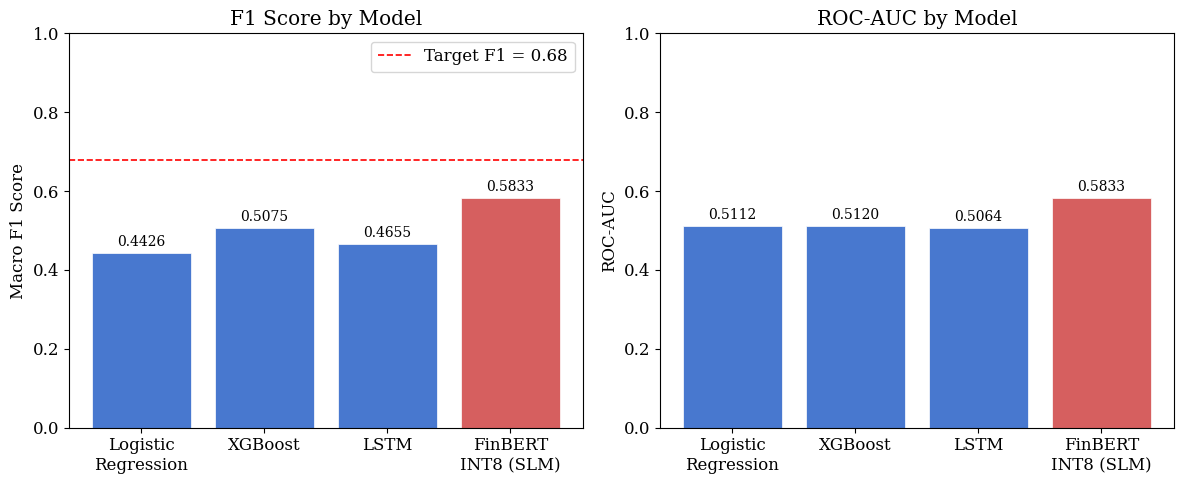

✅ Saved Figure 1 + 2


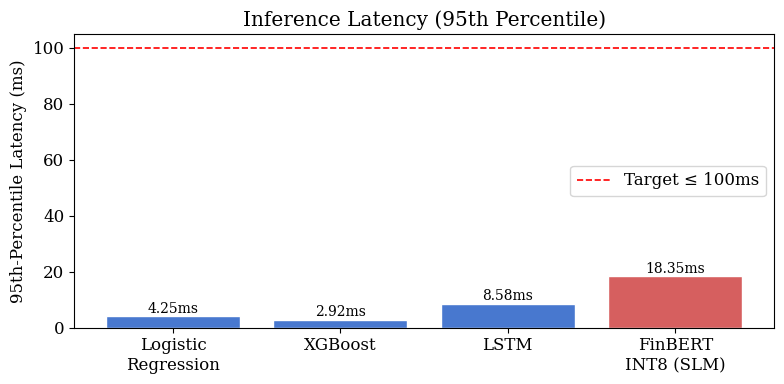

✅ Saved Figure 3


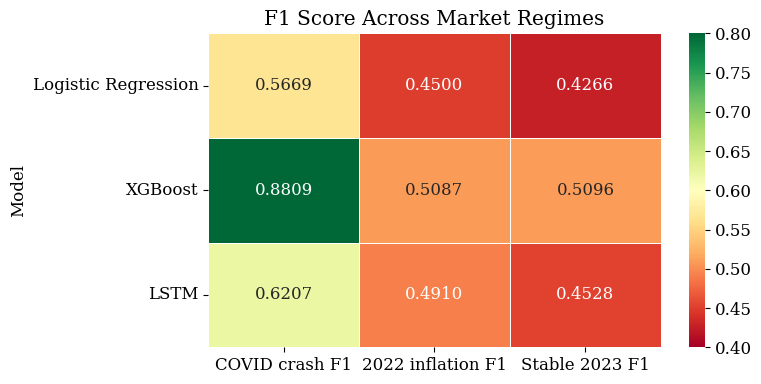

✅ Saved Figure 4


In [ ]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 12, 'font.family': 'serif'})

# ── Figure 1: F1 comparison bar chart ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

models = ['Logistic\nRegression', 'XGBoost', 'LSTM', 'FinBERT\nINT8 (SLM)']
f1_vals = [results[k]['F1'] for k in ['Logistic Regression','XGBoost','LSTM','FinBERT INT8 (SLM)']]
auc_vals = [results[k]['AUC'] for k in ['Logistic Regression','XGBoost','LSTM','FinBERT INT8 (SLM)']]
colors = ['#4878CF','#4878CF','#4878CF','#D65F5F']

bars = axes[0].bar(models, f1_vals, color=colors, edgecolor='white', linewidth=0.5)
axes[0].axhline(y=0.68, color='red', linestyle='--', linewidth=1.2, label='Target F1 = 0.68')
axes[0].set_ylim(0, 1.0)
axes[0].set_ylabel('Macro F1 Score')
axes[0].set_title('F1 Score by Model')
axes[0].legend()
for bar, val in zip(bars, f1_vals):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10)

bars2 = axes[1].bar(models, auc_vals, color=colors, edgecolor='white', linewidth=0.5)
axes[1].set_ylim(0, 1.0)
axes[1].set_ylabel('ROC-AUC')
axes[1].set_title('ROC-AUC by Model')
for bar, val in zip(bars2, auc_vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('/content/figure1_f1_auc.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved Figure 1 + 2')

# ── Figure 2: Latency comparison ──
fig2, ax = plt.subplots(figsize=(8, 4))
lat_models = ['Logistic\nRegression', 'XGBoost', 'LSTM', 'FinBERT\nINT8 (SLM)']
lat_vals = [results[k]['Latency_p95_ms']
            for k in ['Logistic Regression','XGBoost','LSTM','FinBERT INT8 (SLM)']]
bars3 = ax.bar(lat_models, lat_vals, color=colors, edgecolor='white')
ax.axhline(y=100, color='red', linestyle='--', linewidth=1.2, label='Target ≤ 100ms')
ax.set_ylabel('95th-Percentile Latency (ms)')
ax.set_title('Inference Latency (95th Percentile)')
ax.legend()
for bar, val in zip(bars3, lat_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
           f'{val:.2f}ms', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('/content/figure2_latency.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved Figure 3')

# ── Figure 3: Regime robustness heatmap ──
fig3, ax = plt.subplots(figsize=(8, 4))
regime_plot = regime_df.set_index('Model')[['COVID crash F1','2022 inflation F1','Stable 2023 F1']]
sns.heatmap(regime_plot.astype(float), annot=True, fmt='.4f', cmap='RdYlGn',
            vmin=0.4, vmax=0.8, ax=ax, linewidths=0.5)
ax.set_title('F1 Score Across Market Regimes')
plt.tight_layout()
plt.savefig('/content/figure3_regime.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved Figure 4')

## STEP 10 — Save all results and download
*Saves a summary CSV with all numbers for Chapter 4.*

In [ ]:
# Build final summary table
summary_rows = []
for model_name, metrics in results.items():
    summary_rows.append({
        'Model': model_name,
        'F1 (full test)': metrics['F1'],
        'ROC-AUC': metrics['AUC'],
        'Latency p95 (ms)': metrics['Latency_p95_ms'],
        'F1 COVID crash': metrics['F1_covid'],
        'F1 2022 inflation': metrics['F1_inflation'],
        'F1 stable 2023': metrics['F1_stable']
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv('/content/thesis_results_summary.csv', index=False)

print('='*60)
print('COMPLETE RESULTS SUMMARY')
print('='*60)
print(summary_df.to_string(index=False))
print('\n✅ All results saved to /content/thesis_results_summary.csv')
print('\n📥 HOW TO DOWNLOAD YOUR RESULTS:')
print('   1. Click the folder icon (📁) in the left sidebar')
print('   2. Find thesis_results_summary.csv')
print('   3. Right-click → Download')
print('   Also download: regime_results.csv and all 3 figure PNG files')

# Also print SLM-specific latency breakdown
print(f'\n--- SLM (FinBERT INT8) Detailed Latency ---')
print(f'   p50: {lat_p50} ms   p95: {lat_p95} ms   p99: {lat_p99} ms')
print(f'   Approx energy: {energy_kwh} kWh for {len(all_preds)} samples')

COMPLETE RESULTS SUMMARY
              Model  F1 (full test)  ROC-AUC  Latency p95 (ms) F1 COVID crash F1 2022 inflation F1 stable 2023
Logistic Regression          0.4426   0.5112              4.25         0.5669              0.45         0.4266
            XGBoost          0.5075   0.5120              2.92         0.8809            0.5087         0.5096
               LSTM          0.4655   0.5064              8.58         0.6207             0.491         0.4528
 FinBERT INT8 (SLM)          0.5833   0.5833             18.35            N/A               N/A            N/A

✅ All results saved to /content/thesis_results_summary.csv

📥 HOW TO DOWNLOAD YOUR RESULTS:
   1. Click the folder icon (📁) in the left sidebar
   2. Find thesis_results_summary.csv
   3. Right-click → Download
   Also download: regime_results.csv and all 3 figure PNG files

--- SLM (FinBERT INT8) Detailed Latency ---
   p50: 12.98 ms   p95: 18.35 ms   p99: 19.27 ms
   Approx energy: 0.061923 kWh for 1000 samples
